<a href="https://colab.research.google.com/github/maisiev/Research_Project_Git/blob/main/Scripts/GEM/GEM_02_Model_Building.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GEM_02: Model Building

In [1]:
!pip install cobra mygene optlang
!pip install cobra
import cobra
!apt-get install glpk-utils

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
glpk-utils is already the newest version (5.0-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [2]:
!pip install cobra highspy
import cobra
import pickle
import os
import numpy as np
from cobra.flux_analysis import pfba
from optlang.symbolics import Zero
import sys
import mygene
import pandas as pd

pd.set_option("display.max_colwidth", 55)
pd.set_option("display.width",        130)

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1: Data Loading & Map Metabolites to Human-GEM Model¶

### 1.1: Load Human2 GEM (Human-GEM) Model

In [4]:
# Path to Human2 GEM SBML file
GEM_PATH = "/content/Human-GEM.xml"

# Load the model
model = cobra.io.read_sbml_model(GEM_PATH)

print("Model loaded:", model.name)
print("Reactions:", len(model.reactions))
print("Metabolites:", len(model.metabolites))
print("Genes:", len(model.genes))

# Use GLPK (which your logs show is successfully installed)
model.solver = 'glpk'

print("Model loaded:", model.name)
print(f"Solver currently in use: {model.solver.interface.__name__}")

# Test a simulation
solution = model.optimize()
print("Objective Value:", solution.objective_value)

Model loaded: Generic genome-scale metabolic model of Homo sapiens
Reactions: 12931
Metabolites: 8461
Genes: 2848
Model loaded: Generic genome-scale metabolic model of Homo sapiens
Solver currently in use: optlang.glpk_interface
Objective Value: 124.86814837744568


### 1.2: Load GEM Input Data from the GEM_01 Pipeline

This is all the input data in one file to make running this pipeline easier

In [5]:
DATA_PATH = "/content/gem_input_data.pkl"

with open(DATA_PATH, "rb") as f:
    gem_data = pickle.load(f)

metadata        = gem_data["metadata"]
nmr             = gem_data["nmr"]
microbiome      = gem_data["microbiome"]
pathways        = gem_data["pathways"]
mean_expr       = gem_data["mean_expr"]
mean_expr_high  = gem_data["mean_expr_high"]
mean_expr_low   = gem_data["mean_expr_low"]
metabolite_map  = gem_data["metabolite_map"]
gem_metabolites = gem_data["gem_metabolites"]
common_ids      = gem_data["common_ids"]

print("Loaded GEM input data.")
print("Samples:", len(common_ids))
print("Metabolites for constraints:", gem_metabolites)


Loaded GEM input data.
Samples: 18
Metabolites for constraints: ['Succinic acid', 'Lactic acid', 'Proline', 'Lysine', 'Alanine', 'Tyrosine', 'Isoleucine', 'Tryptophan', 'Glucose', 'Arginine']


In [6]:
print("Metadata shape:", metadata.shape)
print("NMR shape:", nmr.shape)
print("Microbiome shape:", microbiome.shape)
print("Pathways shape:", pathways.shape)
print("Mean expr shape:", mean_expr.shape)
print("Metabolite map:", metabolite_map)

Metadata shape: (18, 16)
NMR shape: (18, 38)
Microbiome shape: (18, 44)
Pathways shape: (18, 250)
Mean expr shape: (23017, 11)
Metabolite map: {'Succinic acid': 'MAM02943c', 'Lactic acid': 'MAM02403c', 'Proline': 'MAM02770c', 'Lysine': 'MAM02426c', 'Alanine': 'MAM01307c', 'Tyrosine': 'MAM03101c', 'Isoleucine': 'MAM02184c', 'Tryptophan': 'MAM03089c', 'Glucose': 'MAM01965c', 'Arginine': 'MAM01365c'}


### 1.3: Create Human-GEM Exchange Reaction ID Map - to use for Constraining Model

In [7]:
# Human_GEM Exchange Reaction IDs - for applying uptake/secretion constraints
# Exchange mapping dictionary for each metabolite and its corresponding Human_GEM ID
# Use these IDs to add constraints
exchange_map = {
    "Succinic acid": "MAR09415",
    "Lactic acid":   "MAR09135",
    "Proline":       "MAR09068",
    "Lysine":        "MAR09041",
    "Alanine":       "MAR09061",
    "Tyrosine":      "MAR09064",
    "Isoleucine":    "MAR09039",
    "Tryptophan":    "MAR09045",
    "Glucose":       "MAR09034",
    "Arginine":      "MAR09066",
    "Urea":          "MAR09081",
    "Ammonia":       "MAR09074",
    "Histidine":     "MAR09040",
    "Protons":       "MAR09048"
}

## 2: Cell-Type Specific Model Comparing High vs Low SA, for Ker1 Cells

### 2.1: Map Gene Symbols to Ensembl IDs¶

In [8]:
# Get mapping table from mygene
mean_expr.index[:10]

mg = mygene.MyGeneInfo()

# Query all gene symbols at once
symbols = list(mean_expr.index)
mapping = mg.querymany(symbols, scopes='symbol', fields='ensembl.gene', species='human')


INFO:biothings.client:querying 1-1000 ...
INFO:biothings.client:querying 1001-2000 ...
INFO:biothings.client:querying 2001-3000 ...
INFO:biothings.client:querying 3001-4000 ...
INFO:biothings.client:querying 4001-5000 ...
INFO:biothings.client:querying 5001-6000 ...
INFO:biothings.client:querying 6001-7000 ...
INFO:biothings.client:querying 7001-8000 ...
INFO:biothings.client:querying 8001-9000 ...
INFO:biothings.client:querying 9001-10000 ...
INFO:biothings.client:querying 10001-11000 ...
INFO:biothings.client:querying 11001-12000 ...
INFO:biothings.client:querying 12001-13000 ...
INFO:biothings.client:querying 13001-14000 ...
INFO:biothings.client:querying 14001-15000 ...
INFO:biothings.client:querying 15001-16000 ...
INFO:biothings.client:querying 16001-17000 ...
INFO:biothings.client:querying 17001-18000 ...
INFO:biothings.client:querying 18001-19000 ...
INFO:biothings.client:querying 19001-20000 ...
INFO:biothings.client:querying 20001-21000 ...
INFO:biothings.client:querying 2100

In [9]:
# Mapping disctionary of gene symbols to ensembl IDs
# Build symbol → ensembl mapping dictionary
symbol_to_ens = {}

for entry in mapping:
    if 'notfound' in entry and entry['notfound']:
        continue
    if 'ensembl' not in entry:
        continue

    ens = entry['ensembl']

    # If multiple Ensembl IDs, take the first
    if isinstance(ens, list):
        ens = ens[0]

    if isinstance(ens, dict) and 'gene' in ens:
        symbol_to_ens[entry['query']] = ens['gene']
len(symbol_to_ens)

17618

In [10]:
# Apply mapping to expression matrices of single cell data (and SA high/low sc data)
def convert_expr_to_ensembl(expr_df, mapping_dict):
    # Keep only genes that mapped
    expr_df = expr_df.loc[expr_df.index.intersection(mapping_dict.keys())].copy()

    # Rename index to Ensembl IDs
    expr_df.index = expr_df.index.map(mapping_dict)

    # Remove duplicates (multiple symbols → same Ensembl)
    expr_df = expr_df.groupby(expr_df.index).mean()

    return expr_df

mean_expr_ens      = convert_expr_to_ensembl(mean_expr, mapping_dict=symbol_to_ens)
mean_expr_high_ens = {}
mean_expr_low_ens  = {}

for ct in mean_expr_high.keys():
    mean_expr_high_ens[ct] = convert_expr_to_ensembl(mean_expr_high[ct], symbol_to_ens)
    mean_expr_low_ens[ct]  = convert_expr_to_ensembl(mean_expr_low[ct],  symbol_to_ens)

model_genes = {g.id for g in model.genes}

len(model_genes & set(mean_expr_ens.index))

2448

In [11]:
# Check the genes overlap in model and single cell expression data
# Use the Ensembl-mapped expression matrices
cell_type = "KER1"
expr_high_KER1 = mean_expr_high_ens[cell_type]
expr_low_KER1  = mean_expr_low_ens[cell_type]

print("KER1 High expr genes:", expr_high_KER1.shape)
print("KER1 Low expr genes:", expr_low_KER1.shape)

model_genes = {g.id for g in model.genes}
expr_genes  = set(mean_expr_ens.index)

print("Genes in both model and expression:", len(model_genes & expr_genes))


KER1 High expr genes: (17618,)
KER1 Low expr genes: (17618,)
Genes in both model and expression: 2448


### 2.2: Define KER1 expression and NMR Group means for high vs low SA¶

In [12]:
cell_type = "KER1"

# KER1 expression (Ensembl IDs)
expr_high_KER1 = mean_expr_high_ens[cell_type]   # Series: Ensembl → expr
expr_low_KER1  = mean_expr_low_ens[cell_type]

print("KER1 High expr genes:", expr_high_KER1.shape)
print("KER1 Low expr genes:", expr_low_KER1.shape)

# Group means for NMR (High vs Low SA)
high_ids = metadata[metadata["SA_status"] == "High"].index
low_ids  = metadata[metadata["SA_status"] == "Low"].index

nmr_high_mean = nmr.loc[high_ids].mean()
nmr_low_mean  = nmr.loc[low_ids].mean()

print("NMR High mean shape:", nmr_high_mean.shape)
print("NMR Low mean shape:", nmr_low_mean.shape)

KER1 High expr genes: (17618,)
KER1 Low expr genes: (17618,)
NMR High mean shape: (38,)
NMR Low mean shape: (38,)


### 2.3: Build Reaction Weights from Expression

In [13]:
def build_reaction_weights(model, expr_series, threshold=None):
    """
    Build continuous GIMME reaction weights from a gene expression Series.

    Parameters
    ----------
    model        : cobra.Model
    expr_series  : pd.Series  — index = Ensembl IDs, values = expression levels
    threshold    : float or None
        Expression level below which a reaction is penalised.
        If None (recommended), uses the 10th percentile of nonzero expression
        values — data-driven and robust across different normalisation scales.

    Returns
    -------
    dict {reaction_id: weight}
        weight = max(0, threshold - mean_gene_expression_for_reaction)
        0.0  → reaction fully supported by expression (no penalty)
        >0.0 → reaction penalised proportionally to expression deficit
    """
    nonzero_expr = expr_series[expr_series > 0]
    if threshold is None:
        threshold = float(np.percentile(nonzero_expr, 10)) if len(nonzero_expr) > 0 else 0.1

    expr_index = set(expr_series.index)
    weights = {}

    for rxn in model.reactions:
        if not rxn.genes:
            # no gene association means transport/exchange/spontaneous so no penalty
            weights[rxn.id] = 0.0
            continue

        gene_exprs = [
            float(expr_series[g.id])
            for g in rxn.genes
            if g.id in expr_index
        ]

        if not gene_exprs:
            # all genes unmapped - treat as absent (maximum penalty)
            weights[rxn.id] = 1.0
        else:
            avg_expr = float(np.mean(gene_exprs))
            # continuous penalty: the further below the threshold, the higher the cost
            weights[rxn.id] = max(0.0, threshold - avg_expr)

    return weights, threshold

# Build weights for KER1 High and Low SA groups
weights_high_KER1, thresh_high = build_reaction_weights(model, expr_high_KER1)
weights_low_KER1,  thresh_low  = build_reaction_weights(model, expr_low_KER1)

print(f"Expression threshold (High SA): {thresh_high:.4f}")
print(f"Expression threshold (Low SA):  {thresh_low:.4f}")

# Sanity check: how many reactions are penalised in each group?
n_penalised_high = sum(1 for w in weights_high_KER1.values() if w > 0)
n_penalised_low  = sum(1 for w in weights_low_KER1.values()  if w > 0)

print(f"Reactions penalised — High SA: {n_penalised_high} / {len(weights_high_KER1)}")
print(f"Reactions penalised — Low SA:  {n_penalised_low}  / {len(weights_low_KER1)}")

# How many reactions differ in weight between the two groups?
common_rxns = set(weights_high_KER1) & set(weights_low_KER1)
n_different = sum(
    1 for r in common_rxns
    if abs(weights_high_KER1[r] - weights_low_KER1[r]) > 1e-6
)
print(f"Reactions with different weights (High vs Low): {n_different}")


Expression threshold (High SA): 0.0030
Expression threshold (Low SA):  0.0047
Reactions penalised — High SA: 1473 / 12931
Reactions penalised — Low SA:  1849  / 12931
Reactions with different weights (High vs Low): 1440


### 2.4: Apply NMR-Based Metabolite Constraints

In [14]:
def apply_metabolite_constraints(base_model, nmr_profile, exchange_map, scale=0.01):
    """
    base_model: COBRA model
    nmr_profile: Series, index includes metabolite names used in exchange_map
    exchange_map: dict {metabolite_name: reaction_id}
    scale: converts NMR units to flux bounds (tunable)
    We classify each metabolite as:
        "uptake" (cell consumes them from environment)
        "secreted" (cell releases them into environment)
    and apply bounds accordingly.
    """
# Metabolite classification
# uptake   → constrain lower_bound  (how much the cell can import)
# secreted → constrain upper_bound  (how much the cell can export)
METABOLITE_DIRECTION = {
    "Succinic acid" : "secreted",   # TCA overflow / microbial product, accumulates
    "Lactic acid"   : "secreted",   # Warburg-like fermentation product
    "Proline"       : "uptake",     # AA: consumed by cells
    "Lysine"        : "uptake",     # AA: essential, consumed
    "Alanine"       : "uptake",     # AA: consumed
    "Tyrosine"      : "uptake",     # AA: consumed
    "Isoleucine"    : "uptake",     # AA: essential, consumed
    "Tryptophan"    : "uptake",     # AA: essential, consumed by SA and host
    "Glucose"       : "uptake",     # Primary energy substrate
    "Arginine"      : "uptake",     # AA: consumed, also NO precursor
}

# --- Calibrate scale factor using glucose as anchor -------------------------
# Target: keratinocyte glucose uptake flux ~1 mmol/gDW/h (literature midpoint)
TARGET_GLUCOSE_FLUX = 1.0   # mmol/gDW/h — adjust if you have better estimates

# Use the overall NMR mean (all 18 samples) to set a stable anchor
nmr_all_mean = nmr.mean()
glucose_nmr_mean = float(nmr_all_mean["Glucose"])

if glucose_nmr_mean > 0:
    SCALE = TARGET_GLUCOSE_FLUX / glucose_nmr_mean
else:
    SCALE = 0.01  # fallback

print(f"\nNMR glucose mean (all samples): {glucose_nmr_mean:.1f}")
print(f"Calibrated scale factor:        {SCALE:.6f}")
print(f"This maps glucose NMR → {TARGET_GLUCOSE_FLUX} mmol/gDW/h flux")

# Quick check: what bounds does this give for each metabolite?
print("\nResulting flux bounds per metabolite (High SA group):")
print(f"{'Metabolite':<18} {'NMR level':>10} {'Direction':>10} {'Bound (mmol/gDW/h)':>20}")
print("-" * 62)
for met, rxn_id in exchange_map.items():
    level = float(nmr_high_mean.get(met, 0))
    bound = SCALE * level
    direction = METABOLITE_DIRECTION.get(met, "uptake")
    bound_str = f"lb = -{bound:.3f}" if direction == "uptake" else f"ub = +{bound:.3f}"
    print(f"{met:<18} {level:>10.1f} {direction:>10} {bound_str:>20}")

def apply_metabolite_constraints(base_model, nmr_profile, exchange_map,
                                  metabolite_direction, scale=SCALE):
  """
  Apply NMR-derived flux bounds to exchange reactions.

  For uptake metabolites (amino acids, glucose):
      lower_bound = -scale * NMR_level
      (negative = import direction in COBRApy convention)

  For secreted metabolites (lactate, succinate):
      upper_bound = +scale * NMR_level
      (positive = export direction)
      lower_bound is left at its model default (usually 0 or -1000)

  Parameters
  ----------
  base_model          : cobra.Model (not modified — a copy is returned)
  nmr_profile         : pd.Series, index = metabolite names
  exchange_map        : dict {metabolite_name: reaction_id}
  metabolite_direction: dict {metabolite_name: "uptake" | "secreted"}
  scale               : float, NMR units → mmol/gDW/h conversion factor

  Returns
  -------
  cobra.Model (copy with bounds applied)
  """
  m = base_model.copy()
  for met_name, rxn_id in exchange_map.items():
    if met_name not in nmr_profile.index:
      continue

    level = float(nmr_profile[met_name])
    flux  = scale * level
    rxn   = m.reactions.get_by_id(rxn_id)
    direction = metabolite_direction.get(met_name, "uptake")

    if direction == "uptake":
            # Restrict how much the cell can import
            # More metabolite available → loosen the bound (less negative)
            # Fewer metabolites available → tighten it (more negative, but bounded)
          rxn.lower_bound = -flux
    else:
            # Secreted: restrict how much can be exported
            # More metabolite in high-SA skin → allow higher secretion
          rxn.upper_bound = flux

  return m

# Build constrained models
model_high_KER1 = apply_metabolite_constraints(
    model, nmr_high_mean, exchange_map, METABOLITE_DIRECTION
)
model_low_KER1 = apply_metabolite_constraints(
    model, nmr_low_mean, exchange_map, METABOLITE_DIRECTION
)

# Verify constraints are actually different between High and Low
print("\nConstraint comparison (High vs Low SA):")
print(f"{'Metabolite':<18} {'High lb/ub':>12} {'Low lb/ub':>12} {'Delta':>10}")
print("-" * 55)
for met, rxn_id in exchange_map.items():
    rxn_h = model_high_KER1.reactions.get_by_id(rxn_id)
    rxn_l = model_low_KER1.reactions.get_by_id(rxn_id)
    direction = METABOLITE_DIRECTION.get(met, "uptake")
    if direction == "uptake":
        bh, bl = rxn_h.lower_bound, rxn_l.lower_bound
    else:
        bh, bl = rxn_h.upper_bound, rxn_l.upper_bound
    delta = bh - bl
    print(f"{met:<18} {bh:>12.4f} {bl:>12.4f} {delta:>10.4f}")




NMR glucose mean (all samples): 0.1
Calibrated scale factor:        12.700903
This maps glucose NMR → 1.0 mmol/gDW/h flux

Resulting flux bounds per metabolite (High SA group):
Metabolite          NMR level  Direction   Bound (mmol/gDW/h)
--------------------------------------------------------------
Succinic acid             0.5   secreted          ub = +5.986
Lactic acid               4.2   secreted         ub = +53.606
Proline                   0.2     uptake          lb = -2.540
Lysine                    0.3     uptake          lb = -3.571
Alanine                   2.0     uptake         lb = -25.304
Tyrosine                  0.3     uptake          lb = -3.755
Isoleucine                0.6     uptake          lb = -7.306
Tryptophan                0.1     uptake          lb = -0.660
Glucose                   0.1     uptake          lb = -0.993
Arginine                  0.6     uptake          lb = -8.013
Urea                      0.0     uptake          lb = -0.000
Ammonia        

### Mapping and Pathophysiology
Creates a dictionary that translates HUMAnN2 pathway names into Metabolite Constraints

In [15]:
# Expanded mapping for Human-GEM IDs
# Use these IDs to set manual environmental pressures
mar_pathophys_map = {
    "Glucose": "MAR09034",
    "Arginine": "MAR09066",
    "Histidine": "MAR09040",
    "Urea": "MAR09081",
    "Iron_Fe2": "MAR09142",
    "Iron_Fe3": "MAR09143",
    "Tryptophan": "MAR09045",
    "Protons": "MAR09048",
    "Lactate": "MAR09135"
}

def apply_disease_context(model, condition_type):
    """
    Manually adjusts the 'battleground' metabolites based on clinical data.
    High SA = Bacteria stealing nutrients & changing pH.
    """
    m = model.copy()

    if condition_type == 'high':
        # 1. Simulate Bacterial Nutrient Theft (Tighten Uptake Bounds)
        m.reactions.get_by_id(mar_pathophys_map["Arginine"]).lower_bound = -2.0  # Restricted
        m.reactions.get_by_id(mar_pathophys_map["Histidine"]).lower_bound = -1.0 # Very restricted (Barrier loss)
        m.reactions.get_by_id(mar_pathophys_map["Iron_Fe2"]).lower_bound = -0.1  # S. aureus steals iron

        # 2. Adjust for pH (Alkaline 5.3) - Easier to export Protons
        m.reactions.get_by_id(mar_pathophys_map["Protons"]).lower_bound = -1000.0

    elif condition_type == 'low':
        # 1. Normal Nutrient Availability (Open Bounds)
        m.reactions.get_by_id(mar_pathophys_map["Arginine"]).lower_bound = -10.0
        m.reactions.get_by_id(mar_pathophys_map["Histidine"]).lower_bound = -5.0
        m.reactions.get_by_id(mar_pathophys_map["Iron_Fe2"]).lower_bound = -5.0

        # 2. Adjust for pH (Acidic 4.6) - Harder to export Protons (Back-pressure)
        m.reactions.get_by_id(mar_pathophys_map["Protons"]).lower_bound = -500.0

    return m

### 2.5: Build Model for KER 1 High and Low and Compare Fluxes¶

In [16]:
# Set the global configuration to GLPK
cobra.Configuration().solver = "glpk"
from cobra.util.solver import linear_reaction_coefficients

from optlang.symbolics import Zero

def run_gimme_efficient(model, reaction_weights, fraction_of_optimum=0.5):
    # 1. Calculate the required growth bound
    # (Using the biomass value 124.868 we already found to save time)
    required_growth = 124.868 * fraction_of_optimum

    # 2. Identify the biomass reaction
    biomass_rxn = list(linear_reaction_coefficients(model).keys())[0]

    # Save the original state to restore later
    original_objective = model.objective
    original_lower_bound = biomass_rxn.lower_bound

    # 3. Apply the constraint
    biomass_rxn.lower_bound = required_growth

    # 4. Build the weighted objective efficiently
    # We only add reactions that actually have weights to the math problem
    objective_dict = {}
    for rxn_id, weight in reaction_weights.items():
        if weight > 0 and rxn_id in model.reactions:
            rxn = model.reactions.get_by_id(rxn_id)
            objective_dict[rxn.forward_variable] = weight
            objective_dict[rxn.reverse_variable] = weight

    # Clear the old objective and set the new GIMME one
    model.objective = model.problem.Objective(Zero, direction="min")
    model.objective.set_linear_coefficients(objective_dict)

    # 5. Solve
    print(f"Solving GIMME for weights...")
    sol = model.optimize()

    # 6. RESTORE the model to its original state
    biomass_rxn.lower_bound = original_lower_bound
    model.objective = original_objective

    return sol

In [17]:
# 1. Prepare models with disease context
model_high_ctx = apply_disease_context(model, 'high')
model_low_ctx  = apply_disease_context(model, 'low')

# 2. Run GIMME (Efficient version using MAR13082 biomass)
# This now integrates scRNA-seq weights + Metabolomics + HUMAnN2 context + pH
sol_high = run_gimme_efficient(model_high_ctx, weights_high_KER1)
sol_low  = run_gimme_efficient(model_low_ctx,  weights_low_KER1)

# 3. Calculate Directional Flux Difference
if sol_high and sol_low:
    raw_diff = sol_high.fluxes - sol_low.fluxes

    print("--- Top Upregulated Fluxes in High S. aureus Keratinocytes ---")
    up = raw_diff.sort_values(ascending=False).head(10)
    for rid, val in up.items():
        name = model.reactions.get_by_id(rid).name
        print(f"{rid}: {name} (+{val:.2f})")

Solving GIMME for weights...
Solving GIMME for weights...
--- Top Upregulated Fluxes in High S. aureus Keratinocytes ---
MAR10032: Transport of Prostaglandin A2, Intracellular (+1000.00)
MAR03016:  (+1000.00)
MAR01321:  (+1000.00)
MAR09437: Exchange of uracil (+996.57)
MAR04882:  (+996.57)
MAR09861: Exchange of xanthosine (+990.30)
MAR09833: Transport of Xanthine (+990.30)
MAR04579: uridine:phosphate alpha-D-ribosyltransferase (+984.24)
MAR01528: Sodium/Ammonium Proton Antiporter (+427.15)
MAR05127:  (+427.15)


In [19]:
# 1. Use raw_diff (the one you just calculated)
# We take the absolute value just to find which ones CHANGED the most,
# regardless of direction, to get the subsystems.
diff_magnitude = raw_diff.abs().sort_values(ascending=False)
changed_rxns = diff_magnitude.index.tolist()

# 2. Get the subsystem for each reaction
subsystems = [model.reactions.get_by_id(rid).subsystem[0] if model.reactions.get_by_id(rid).subsystem else "Unknown" for rid in changed_rxns]

# 3. Count which subsystems appear most in the top 100 changes
from collections import Counter
subsystem_counts = Counter(subsystems[:100])

print("Top 10 Metabolic Subsystems shifting due to S. aureus/pH Context:")
for sub, count in subsystem_counts.most_common(10):
    print(f"{sub}: {count} reactions")

print("\n--- Detail for Top 10 Most Shifted Reactions ---")
# 4. Check the full names and the DIRECTION of the shift
for rxn_id in diff_magnitude.index[:10]:
    rxn = model.reactions.get_by_id(rxn_id)
    shift_val = raw_diff[rxn_id]
    direction = "UP" if shift_val > 0 else "DOWN"
    print(f"[{direction}] {rxn_id} | {rxn.subsystem[0]} | {rxn.name} (Change: {shift_val:.2f})")

Top 10 Metabolic Subsystems shifting due to S. aureus/pH Context:
T: 44 reactions
E: 25 reactions
P: 13 reactions
C: 4 reactions
G: 3 reactions
S: 3 reactions
A: 2 reactions
N: 2 reactions
M: 1 reactions
L: 1 reactions

--- Detail for Top 10 Most Shifted Reactions ---
[UP] MAR10032 | T | Transport of Prostaglandin A2, Intracellular (Change: 1000.00)
[DOWN] MAR05035 | T |  (Change: -1000.00)
[DOWN] MAR11367 | T | Transport of Prostaglandin E2, Mitochondrial (Change: -1000.00)
[DOWN] MAR09439 | E | Exchange of uridine (Change: -1000.00)
[UP] MAR03016 | E |  (Change: 1000.00)
[UP] MAR01321 | P |  (Change: 1000.00)
[UP] MAR09437 | E | Exchange of uracil (Change: 996.57)
[UP] MAR04882 | T |  (Change: 996.57)
[DOWN] MAR11428 | E | Exchange of xanthine (Change: -990.30)
[UP] MAR09861 | E | Exchange of xanthosine (Change: 990.30)


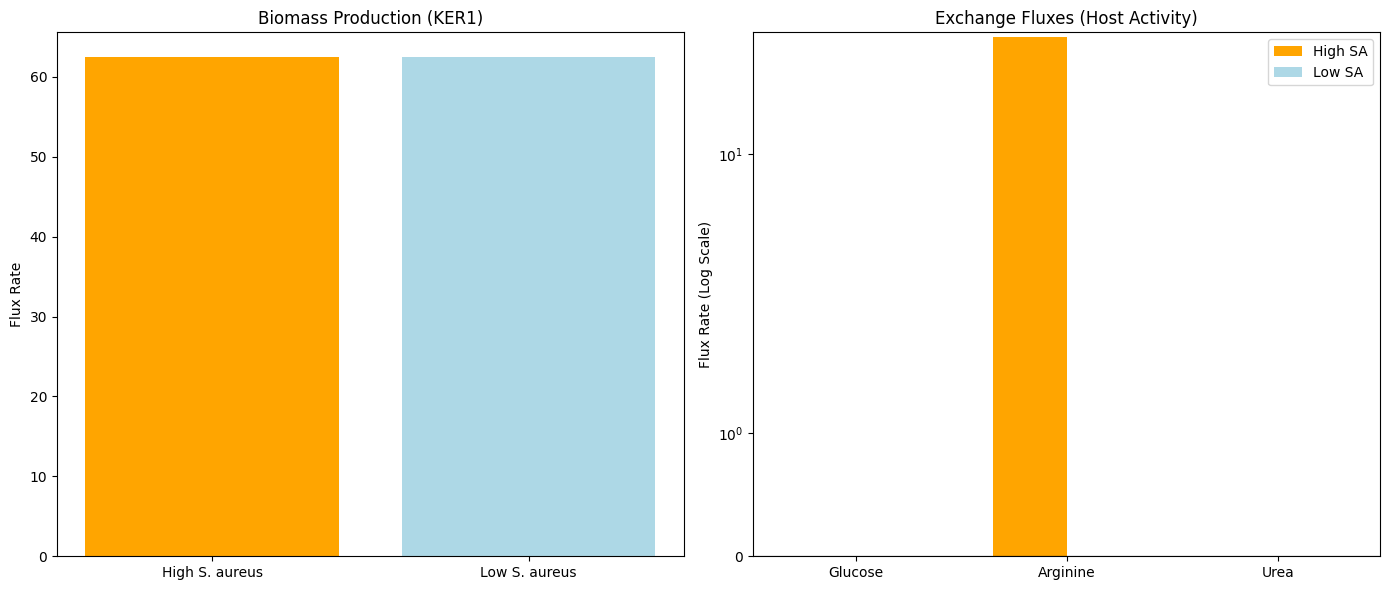

In [25]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_multi_omic_results(sol_high, sol_low, cell_type="KER1"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot A: Biomass Comparison
    high_growth = sol_high.fluxes["MAR13082"]
    low_growth  = sol_low.fluxes["MAR13082"]

    axes[0].bar(['High S. aureus', 'Low S. aureus'], [high_growth, low_growth], color=['orange', 'lightblue'])
    axes[0].set_title(f'Biomass Production ({cell_type})')
    axes[0].set_ylabel('Flux Rate')

    # Plot B: Key Exchange Fluxes (Directionality)
    # We look at Arginine, Urea, and Glucose
    keys = ["MAR09034", "MAR09066", "MAR09081"] # Glucose, Arginine, Urea
    labels = ["Glucose", "Arginine", "Urea"]

    high_ex = [sol_high.fluxes[k] for k in keys]
    low_ex  = [sol_low.fluxes[k] for k in keys]

    x = np.arange(len(labels))
    width = 0.35

    axes[1].bar(x - width/2, high_ex, width, label='High SA', color='orange')
    axes[1].bar(x + width/2, low_ex, width, label='Low SA', color='lightblue')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)
    axes[1].set_yscale('symlog')
    axes[1].set_ylabel('Flux Rate (Log Scale)')
    axes[1].set_title('Exchange Fluxes (Host Activity)')
    axes[1].legend()
    axes[1].axhline(0, color='black', lw=0.8)

    plt.tight_layout()
    plt.show()

visualize_multi_omic_results(sol_high, sol_low)

In [22]:
# Print the exact values for the plot
keys = ["MAR09034", "MAR09066", "MAR09081"] # Glucose, Arginine, Urea
labels = ["Glucose", "Arginine", "Urea"]

print("--- Exact Exchange Fluxes ---")
for i, k in enumerate(keys):
    print(f"{labels[i]} (High SA): {sol_high.fluxes[k]:.4f}")
    print(f"{labels[i]} (Low SA):  {sol_low.fluxes[k]:.4f}")

--- Exact Exchange Fluxes ---
Glucose (High SA): 0.0000
Glucose (Low SA):  0.0000
Arginine (High SA): 33.5131
Arginine (Low SA):  0.0000
Urea (High SA): 0.0000
Urea (Low SA):  0.0000
